In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Imports and Data Loading**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

df = pd.read_csv('/content/drive/MyDrive/neural assignment/bank-full.csv', sep=';')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


**Data Preprocessing**

In [3]:
df['y'] = df['y'].map({'yes': 1, 'no': 0})
df_final = pd.get_dummies(df, drop_first=True)

X = df_final.drop('y', axis=1)
y = df_final['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Feature Scaling**

In [4]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**Model Training**

In [5]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

**Model Evaluation**

In [6]:
y_pred = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8988167643481145
[[7755  197]
 [ 718  373]]
              precision    recall  f1-score   support

           0       0.92      0.98      0.94      7952
           1       0.65      0.34      0.45      1091

    accuracy                           0.90      9043
   macro avg       0.78      0.66      0.70      9043
weighted avg       0.88      0.90      0.88      9043



**the README file **

In [8]:
import os

if os.path.exists("README.md"):
    os.remove("README.md")

In [9]:
!cat README.md

cat: README.md: No such file or directory


In [16]:
%%writefile README.md
Bank Marketing Prediction

## Approach
The goal of this project was to develop a predictive model to determine if a banking customer would subscribe to a term deposit based on their demographic and behavioral data. The project followed a standard data science pipeline: data loading, exploratory analysis, categorical encoding, feature scaling, and binary classification using Logistic Regression.

## Methodology
- Data Preprocessing: The target variable 'y' was mapped to binary values (1 for 'yes', 0 for 'no'). Categorical features such as 'job', 'education', and 'contact' were transformed using One-Hot Encoding to expand them into machine-readable numerical formats.
- Data Splitting: The dataset was split into an 80% training set and a 20% testing set to ensure unbiased evaluation.
- Feature Scaling: Since Logistic Regression is sensitive to the magnitude of input variables, `StandardScaler` was applied to normalize all features to a mean of 0 and a standard deviation of 1.
- Model Training: A Logistic Regression model was trained using the Scikit-learn library, with the maximum iterations increased to 1000 to ensure the solver reached convergence.
- Evaluation: The model performance was assessed using a Confusion Matrix, Accuracy Score, and a detailed Classification Report (Precision, Recall, and F1-Score).

## Findings
Overall Accuracy: The model achieved an accuracy of approximately 89.88%, indicating strong predictive power for the majority of cases.
- Confusion Matrix:
    - True Negatives (Correctly predicted 'no'): 7755
    - True Positives (Correctly predicted 'yes'): 373
    - False Positives: 197
    - False Negatives: 718
- Class Performance:
    - The model is highly effective at identifying customers who will not subscribe (Recall for '0' = 0.98).
    - The recall for the 'yes' class (0.34) suggests that the model is conservative in its predictions, likely due to the inherent class imbalance in the banking dataset where 'no' responses significantly outnumber 'yes' responses.
- Conclusion: The Logistic Regression model provides a reliable baseline for the bank to filter out unlikely subscribers, though further tuning or class-weight adjustments could be explored to improve the detection of potential subscribers.

Overwriting README.md


**Confusion Matrix Heatmap**

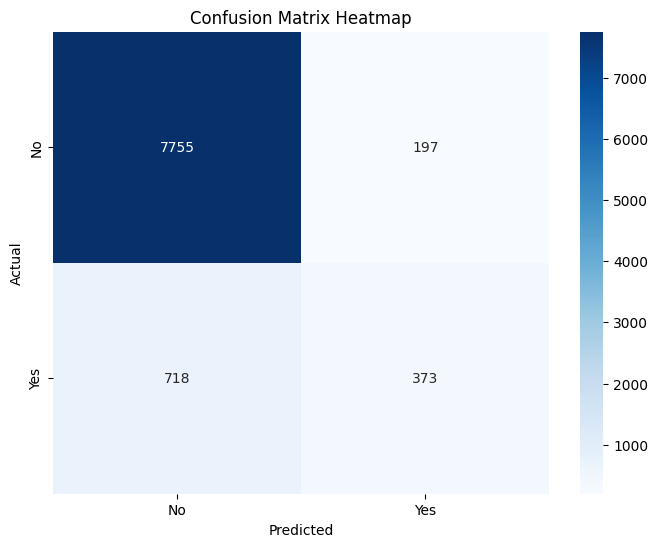

In [11]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.show()

**Top 10 Most Influential Features**

/tmp/ipykernel_370/2936431579.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')


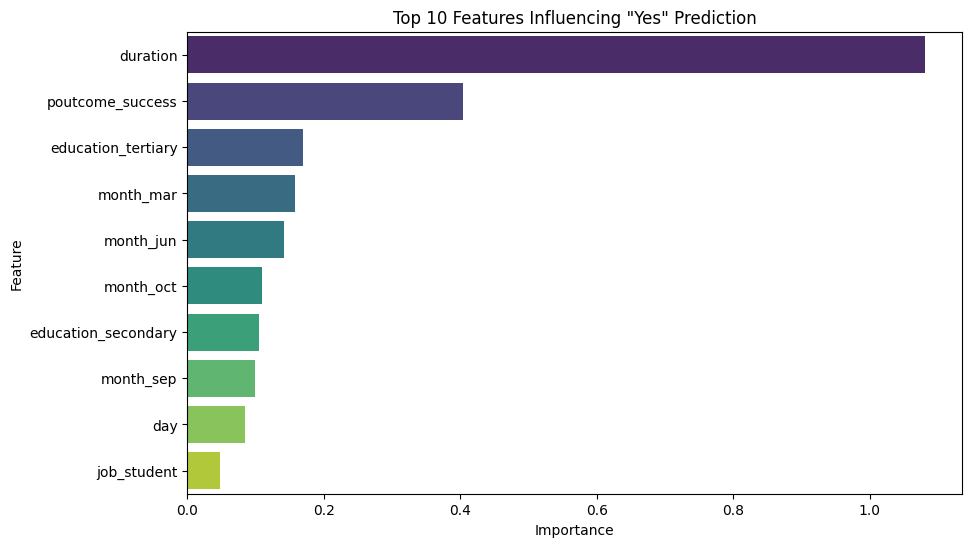

In [12]:
importance = model.coef_[0]
feature_names = X.columns
feature_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')
plt.title('Top 10 Features Influencing "Yes" Prediction')
plt.show()

**Correlation Heatmap (Selected Features)**

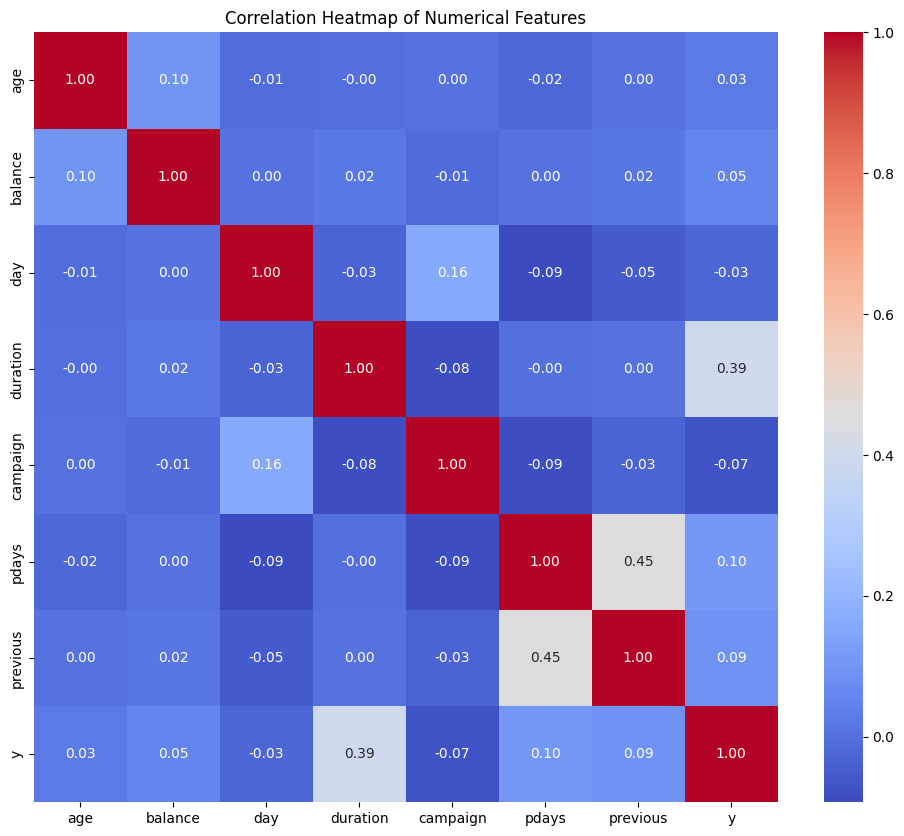

In [13]:
plt.figure(figsize=(12, 10))
correlation_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

In [18]:
import shutil
shutil.copy("README.md", "/content/drive/MyDrive/neural assignment/bank readme")

'/content/drive/MyDrive/neural assignment/bank readme/README.md'